In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.model_selection import train_test_split
import csv

Matplotlib is building the font cache; this may take a moment.


In [3]:
import torchvision

In [4]:
import torchvision.transforms as transforms

Setting device on gpu

In [ ]:

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA")
else:
    device = torch.device("cpu")
    print("CPU")

Success! Using Apple Silicon M2 GPU acceleration (MPS).


In [10]:
device

device(type='cpu')

Loading Dataset


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    
])


train_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False,
    download=True, 
    transform=transform
)

Files already downloaded and verified
Files already downloaded and verified


Residual / Skip Connection


In [ ]:
class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        
        self.my_conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.my_bn1 = nn.BatchNorm2d(out_channels)
        
        
        self.my_conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.my_bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        
        self.shapechange = (stride != 1) or (in_channels != out_channels)
        
        if self.shapechange:
            
            self.fix_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)
            self.fix_bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        
        original_input = x
        
        
        out = self.my_conv1(x)
        out = self.my_bn1(out)
        out = self.relu(out)
        
        
        out = self.my_conv2(out)
        out = self.my_bn2(out)
        
        
        if self.shapechange:
            original_input = self.fix_conv(original_input)
            original_input = self.fix_bn(original_input)
            
        
        out = out + original_input
        
        
        out = self.relu(out)
        
        return out

In [ ]:
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        
        self.front_conv = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1, bias=False)
        self.front_bn = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()
        
       
        self.stage1_block1 = Residual(in_channels=32, out_channels=32, stride=1)
        self.stage1_block2 = Residual(in_channels=32, out_channels=32, stride=1)
        
        
        self.stage2_block1 = Residual(in_channels=32, out_channels=64, stride=2)
        self.stage2_block2 = Residual(in_channels=64, out_channels=64, stride=1)
        
       
        self.stage3_block1 = Residual(in_channels=64, out_channels=128, stride=2)
        self.stage3_block2 = Residual(in_channels=128, out_channels=128, stride=1)
        
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        
        out = self.front_conv(x)
        out = self.front_bn(out)
        out = self.relu(out)
        
       
        out = self.stage1_block1(out)
        out = self.stage1_block2(out)
        
        
        out = self.stage2_block1(out)
        out = self.stage2_block2(out)
        
        
        out = self.stage3_block1(out)
        out = self.stage3_block2(out)
        

        out = self.global_pool(out)
        out = torch.flatten(out, start_dim=1) 
        out = self.classifier(out)
        
        return out

In [ ]:

BATCH_SIZE = 64


train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2
)

print(f"Training size: {len(train_loader)}")
print(f"Testing size: {len(test_loader)}")

Training batches: 782
Testing batches: 157


In [ ]:

model = ResNet(num_classes=10)
model = model.to(device)


criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

ResNet(
  (front_conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (front_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (stage1_block1): Residual(
    (my_conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (my_bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (my_conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (my_bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (stage1_block2): Residual(
    (my_conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (my_bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (my_conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (my_bn2): BatchNorm2d(32, eps=1e-05, momentum

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train() 
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        
        inputs, labels = inputs.to(device), labels.to(device)
        
        
        optimizer.zero_grad()
        
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
       
        loss.backward()
        
        
        optimizer.step()
        
       
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    return epoch_loss, epoch_acc

In [ ]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    return epoch_loss, epoch_acc

In [ ]:

EPOCHS = 10


train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

print("Starting training process...")
for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    # Evaluate
    test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)
    
   
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    print(f" [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc}%  "
          f"Test Loss: {test_loss:.4f}  Test Acc: {test_acc}%")
          
print("Training Complete!")

Starting training process...


Epoch [1/10] -> Train Loss: 1.2365 | Train Acc: 54.90% || Test Loss: 1.4790 | Test Acc: 51.08%
Epoch [2/10] -> Train Loss: 0.8180 | Train Acc: 71.00% || Test Loss: 0.9128 | Test Acc: 67.65%
Epoch [3/10] -> Train Loss: 0.6388 | Train Acc: 77.70% || Test Loss: 0.8121 | Test Acc: 72.35%
Epoch [4/10] -> Train Loss: 0.5345 | Train Acc: 81.68% || Test Loss: 0.6550 | Test Acc: 76.92%
Epoch [5/10] -> Train Loss: 0.4603 | Train Acc: 84.11% || Test Loss: 0.7179 | Test Acc: 76.06%
Epoch [6/10] -> Train Loss: 0.3925 | Train Acc: 86.23% || Test Loss: 0.5884 | Test Acc: 80.46%
Epoch [7/10] -> Train Loss: 0.3298 | Train Acc: 88.46% || Test Loss: 0.5702 | Test Acc: 81.03%
Epoch [8/10] -> Train Loss: 0.2782 | Train Acc: 90.35% || Test Loss: 0.6166 | Test Acc: 80.39%
Epoch [9/10] -> Train Loss: 0.2324 | Train Acc: 91.85% || Test Loss: 0.5725 | Test Acc: 82.09%
Epoch [10/10] -> Train Loss: 0.1925 | Train Acc: 93.31% || Test Loss: 0.7384 | Test Acc: 78.17%
Training Complete!


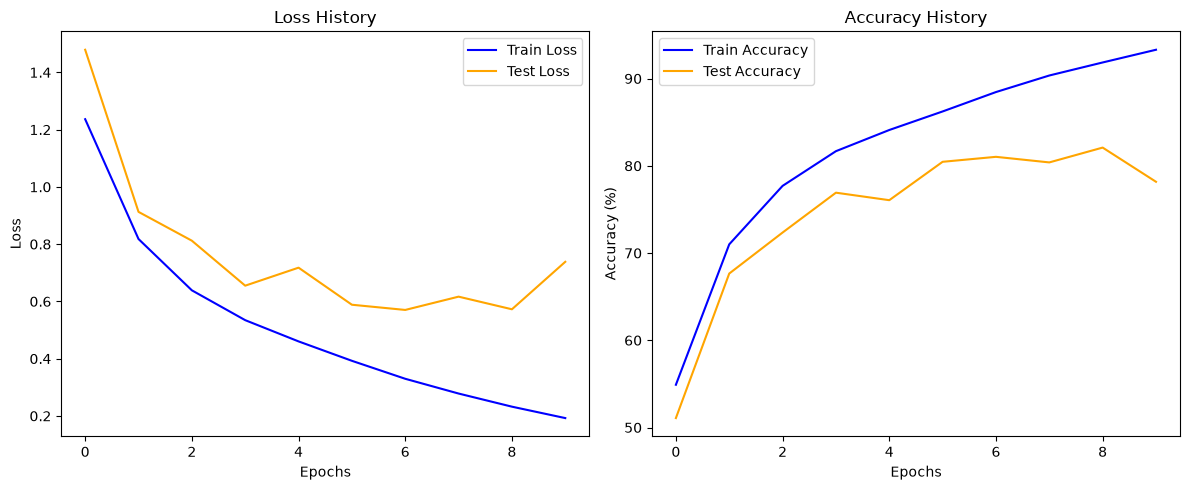

In [ ]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='orange')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue')
plt.plot(test_accuracies, label='Test Accuracy', color='orange')
plt.title('Accuracy History')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
os.makedirs('./models', exist_ok=True)
model_save_path = './models/custom_resnet_cifar10.pth'

torch.save(model.state_dict(), model_save_path)
print(f"Model checkpoint parameters successfully saved to {model_save_path}")

Model checkpoint parameters successfully saved to ./models/custom_resnet_cifar10.pth
